<a href="https://colab.research.google.com/github/akwve/STA160_Group2_Project/blob/main/News_Cloud_LogReg_XGB_SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import files
uploaded = files.upload()

Saving fake_true_news_data.txt to fake_true_news_data.txt


In [2]:
import pandas as pd

df = pd.read_csv("fake_true_news_data.txt")
df['all_words'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df.head()


,title,text,subject,date,year,label,all_words
0,donald trump sends out embarrassing new year’s...,donald trump wish american happy new year leav...,News,2017-12-31,2017.0,False,donald trump sends out embarrassing new year’s...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,News,2017-12-31,2017.0,False,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...,friday revealed former milwaukee sheriff david...,News,2017-12-30,2017.0,False,sheriff david clarke becomes an internet joke ...
3,trump is so obsessed he even has obama’s name ...,christmas day donald trump announced would bac...,News,2017-12-29,2017.0,False,trump is so obsessed he even has obama’s name ...
4,pope francis just called out donald trump duri...,pope francis used annual christmas day message...,News,2017-12-25,2017.0,False,pope francis just called out donald trump duri...


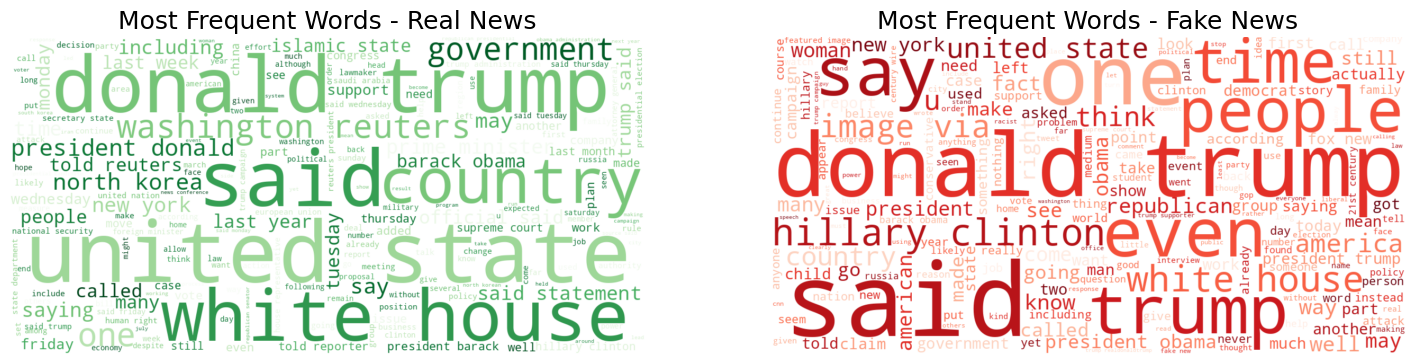

In [3]:
# Generate a WordCloud for both true and false
import matplotlib.pyplot as plt
from wordcloud import WordCloud
true_texts = ' '.join(df[df['label'] == True]['text'].dropna().astype(str))
false_texts = ' '.join(df[df['label'] == False]['text'].dropna().astype(str))

# Create the WordClouds
true_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Greens',
    max_words=200
).generate(true_texts)

false_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    max_words=200
).generate(false_texts)

# Display side-by-side
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.imshow(true_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words - Real News', fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(false_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words - Fake News', fontsize=18)

plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X = df[['all_words']]
y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

vect = TfidfVectorizer()
X_train_tfidf = vect.fit_transform(X_train['all_words'])
X_test_tfidf = vect.transform(X_test['all_words'])


def train(model ,model_name ,X_train ,y_train ,X_test ,y_test):
    model.fit(X_train,y_train)
    model_train_score = model.score(X_train,y_train)
    model_test_score = model.score(X_test,y_test)
    print(f"{model_name} Training data accuracy: {model_train_score * 100}%\n{model_name} Testing data accuracy: {model_test_score * 100}%")

def class_report(model ,X_test , y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

vect = TfidfVectorizer()
X_train_tfidf = vect.fit_transform(X_train['all_words'])
X_test_tfidf = vect.transform(X_test['all_words'])

In [6]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC


lr = LogisticRegression()
train(lr,"Logistic Regression", X_train_tfidf, Y_train, X_test_tfidf, Y_test)

xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.6 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
train(xgboost,"Xgboost", X_train_tfidf, Y_train, X_test_tfidf, Y_test)

svc = LinearSVC()
train(svc, "Linear SVC", X_train_tfidf, Y_train, X_test_tfidf, Y_test)



Logistic Regression model score on Training data: 99.23918212077983%
Logistic Regression model score on Testing data: 98.7692996196017%
Xgboost model score on Training data: 99.66993930239714%
Xgboost model score on Testing data: 99.54128440366972%
Linear SVC model score on Training data: 99.98601437722023%
Linear SVC model score on Testing data: 99.54128440366972%


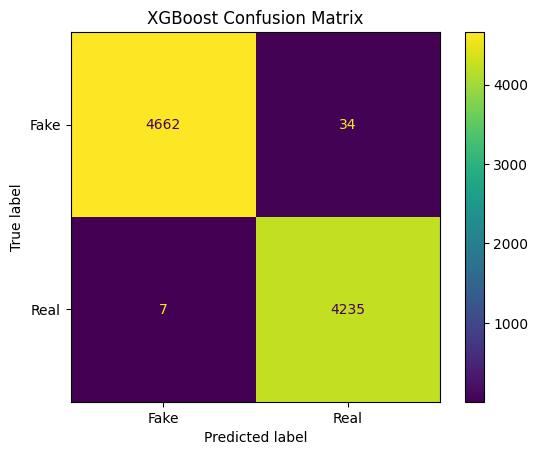

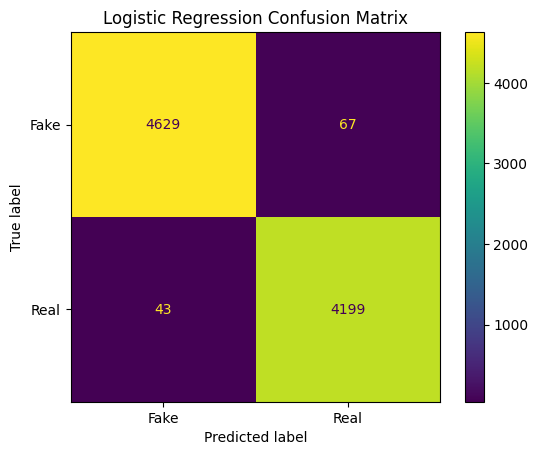

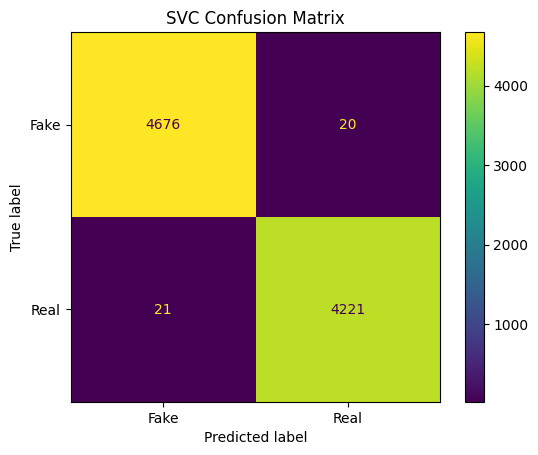

In [7]:
ConfusionMatrixDisplay.from_estimator(
    xgboost,
    X_test_tfidf,
    Y_test,
    display_labels=['Fake', 'Real'],
    )
plt.title("XGBoost Confusion Matrix")
plt.show()


ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_tfidf,
    Y_test,
    display_labels=['Fake', 'Real']
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


ConfusionMatrixDisplay.from_estimator(
    svc,
    X_test_tfidf,
    Y_test,
    display_labels=['Fake', 'Real'],
    )
plt.title("SVC Confusion Matrix")
plt.show()

